# Phase 1 — Version B: the implementable USD portfolio

**Study:** dual_momentum_turkish_investor · SPEC §3a/§6a · signals in USD, reporting in three numeraires (§4)

Universe (locked): SHY IEF GLD XLE SPY QQQ EFA EEM MCHI INDA — MCHI/INDA at actual inception, EM gate
(max one of MCHI/INDA per sub-strategy top-3), hatch = SHY, L ∈ {10,25}, N=3, 50/50 blend, weekly Wednesday.
Costs 10 bps one-way (gross and 25 bps sensitivity also reported). Primary window 2013-01-01 → latest.

**Provisional deflator caveat:** TL-real uses IMF IFS `PCPI_IX` (via DBnomics) until the TÜİK/EVDS layer
lands in Phase 2; the TL-real series truncates at the CPI's last month (2025-07). CPI publication lag is
ignored (reporting only). Benchmarks B1 (TL deposits), B4 (BIST), B6 (50/50) need EVDS → Phase 2;
computable here: B2 = 100% SHY, B3 = 100% GLD, B5 = EW of the Version B universe.

**Terminology (defined in [SPEC.md](SPEC.md) §3a/§4, restated here for readers landing on this notebook first):**
**Version A** = the full Turkish saver's universe — the ten USD ETF sleeves *plus* rolled TL time deposits and BIST-100 total return, with all momentum signals computed in nominal TL (Phase 2).
**Version B** = the implementable subset — the ten USD ETF sleeves only, signals in USD, escape hatch = SHY; everything executable at a single broker today (this notebook).
**A−B gap** = the real-TL performance difference between them: what access to the TL deposit layer is worth to a Turkish investor — the study's key product-relevant output, computed in Phase 2.
**B1–B6** = the fixed benchmark set: B1 rolled TL deposits, B2 100% SHY ("hold dollars"), B3 100% gold, B4 BIST-100 total return, B5 equal-weight of the universe, B6 50/50 deposits/BIST (stylized retail portfolio).


In [1]:
import numpy as np
import pandas as pd
from phase1_version_b import run_phase1, PRIMARY_START, UNIVERSE_B

res = run_phase1()
pd.set_option("display.float_format", lambda x: "%0.4f" % x)
print("=== USD (2013 -> latest) ===");        print(res["tables"]["USD"].to_string())
print()
print("=== TL nominal (2013 -> latest) ===");  print(res["tables"]["TL_nominal"].to_string())
print()
print("=== TL real (2013 -> CPI %s) ===" % res["cpi_last"]); print(res["tables"]["TL_real"].to_string())

=== USD (2013 -> latest) ===
           perf  st_dev  max_dd  sharpe  calmar    weeks
VB_gross 0.1081  0.1234 -0.1733  0.8763  0.6238 712.0000
VB_net10 0.0887  0.1238 -0.1863  0.7163  0.4758 712.0000
VB_net25 0.0600  0.1244 -0.2055  0.4827  0.2922 712.0000
B2_SHY   0.0140  0.0134 -0.0557  1.0509  0.2521 712.0000
B3_GLD   0.0721  0.1620 -0.3831  0.4452  0.1883 712.0000
B5_EW    0.0823  0.1184 -0.2431  0.6954  0.3387 712.0000

=== TL nominal (2013 -> latest) ===
           perf  st_dev  max_dd  sharpe  calmar    weeks
VB_gross 0.4096  0.1886 -0.2437  2.1715  1.6809 712.0000
VB_net10 0.3848  0.1888 -0.2467  2.0382  1.5596 712.0000
VB_net25 0.3484  0.1891 -0.2513  1.8424  1.3864 712.0000
B2_SHY   0.2899  0.1572 -0.2098  1.8440  1.3818 712.0000
B3_GLD   0.3637  0.2076 -0.2298  1.7520  1.5832 712.0000
B5_EW    0.3767  0.1806 -0.2660  2.0856  1.4165 712.0000

=== TL real (2013 -> CPI 2025-07) ===
           perf  st_dev  max_dd  sharpe  calmar    weeks
VB_gross 0.1307  0.2019 -0.3491  0.6473 

In [2]:
for k, v in res["holdings"].items():
    print("%s: %0.3f" % (k, v))
print()
print("=== secondary USD window (2008-02-21 ->, crisis behavior) ===")
print(res["secondary"].to_string())

mean_weekly_oneway_turnover: 0.340
avg_sleeves_held: 4.181
pct_weeks_hatch_active: 0.121
avg_hatch_weight_when_active: 0.318

=== secondary USD window (2008-02-21 ->, crisis behavior) ===
           perf  st_dev  max_dd  sharpe  calmar    weeks
VB_gross 0.1079  0.1269 -0.1733  0.8508  0.6226 966.0000
VB_net10 0.0887  0.1273 -0.1863  0.6971  0.4762 966.0000
B5_EW    0.0751  0.1329 -0.3438  0.5650  0.2185 966.0000


In [3]:
# EM concentration gate (SPEC 6 rule 2): how often does it actually bind?
# Binding = an UNGATED sub-strategy top-3 would contain both MCHI and INDA;
# the gate then keeps the higher-ranked one and promotes the next non-EM sleeve.
from engine import dual_momentum_weights, to_weekly
from bridge_ablation import load_prices
from phase1_version_b import HATCH

pw = to_weekly(load_prices())[UNIVERSE_B]
for L in (10, 25):
    ug = dual_momentum_weights(pw, L, 3, hatch=HATCH).dropna(how="all").loc[PRIMARY_START:]
    both = (ug["MCHI"] > 1e-9) & (ug["INDA"] > 1e-9)
    yrs = pd.Series(both[both].index.year).value_counts().sort_index()
    print("L=%dw: ungated top-3 holds BOTH MCHI & INDA in %d/%d weeks (%.1f%%); by year: %s"
          % (L, both.sum(), len(ug), 100 * both.mean(), dict(yrs)))

L=10w: ungated top-3 holds BOTH MCHI & INDA in 54/713 weeks (7.6%); by year: {2013: np.int64(2), 2014: np.int64(7), 2015: np.int64(4), 2016: np.int64(3), 2017: np.int64(16), 2019: np.int64(5), 2020: np.int64(12), 2021: np.int64(2), 2024: np.int64(3)}


L=25w: ungated top-3 holds BOTH MCHI & INDA in 70/713 weeks (9.8%); by year: {2013: np.int64(10), 2014: np.int64(15), 2015: np.int64(2), 2016: np.int64(6), 2017: np.int64(15), 2019: np.int64(5), 2020: np.int64(11), 2021: np.int64(4), 2024: np.int64(2)}


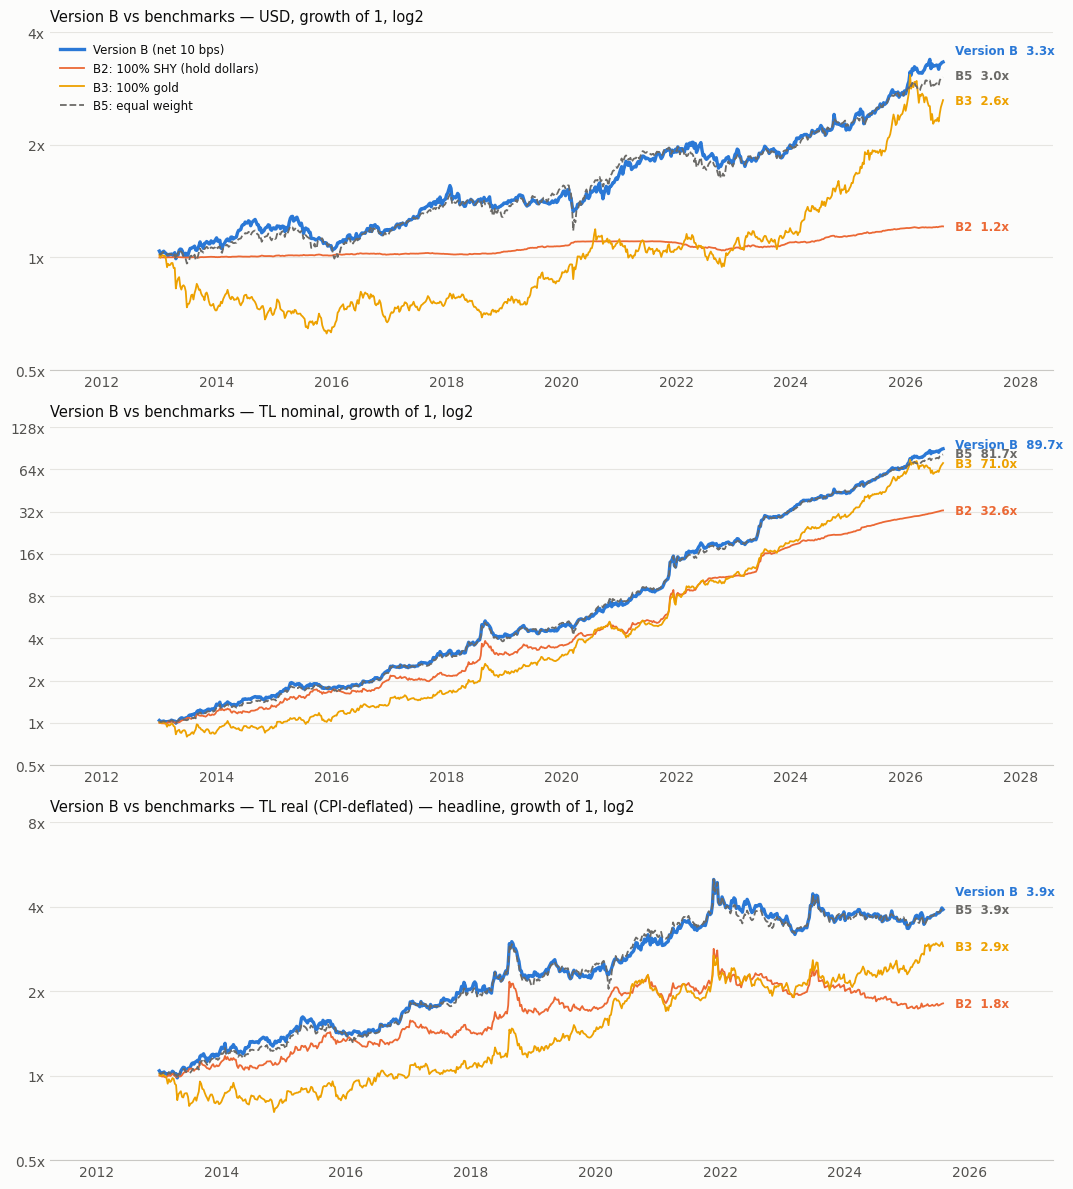

In [4]:
import matplotlib.pyplot as plt

SURFACE = "#fcfcfb"
STYLE = {  # color follows the entity across all charts
    "VB_net10": dict(color="#2a78d6", lw=2.4, ls="-", label="Version B (net 10 bps)"),
    "B2_SHY":   dict(color="#eb6834", lw=1.3, ls="-", label="B2: 100% SHY (hold dollars)"),
    "B3_GLD":   dict(color="#eda100", lw=1.3, ls="-", label="B3: 100% gold"),
    "B5_EW":    dict(color="#6b6a67", lw=1.3, ls="--", label="B5: equal weight"),
}
PANELS = [("USD", "USD"), ("TL_nominal", "TL nominal"), ("TL_real", "TL real (CPI-deflated) — headline")]

fig, axes = plt.subplots(3, 1, figsize=(11, 12), facecolor=SURFACE)
for ax, (num, title) in zip(axes, PANELS):
    ax.set_facecolor(SURFACE)
    for name, st in STYLE.items():
        c = res["curves"][name][num]
        ax.plot(c.index, np.log2(c.values), **st)
    last = sorted((np.log2(res["curves"][n][num].iloc[-1]), n) for n in STYLE)
    prev = None
    for y, n in last:
        if prev is not None and y - prev < 0.22:
            y = prev + 0.22
        prev = y
        ax.annotate(" %s  %.1fx" % (STYLE[n]["label"].split(":")[0].split(" (")[0],
                                    res["curves"][n][num].iloc[-1]),
                    xy=(res["curves"][n][num].index[-1], y), xytext=(6, 0),
                    textcoords="offset points", va="center", color=STYLE[n]["color"],
                    fontsize=8.5, fontweight="bold")
    hi = max(np.log2(res["curves"][n][num].values).max() for n in STYLE)
    lo = min(0, min(np.log2(res["curves"][n][num].values).min() for n in STYLE))
    ticks = range(int(np.floor(lo)), int(np.ceil(hi)) + 1)
    ax.set_yticks(list(ticks))
    ax.set_yticklabels(["%gx" % (2.0 ** k) for k in ticks])
    ax.grid(axis="y", color="#e6e5e1", lw=0.8)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#c9c8c4")
    ax.tick_params(colors="#52514e", length=0)
    ax.set_title("Version B vs benchmarks — %s, growth of 1, log2" % title,
                 color="#0b0b0b", fontsize=10.5, loc="left", pad=8)
    ax.margins(x=0.14)
axes[0].legend(loc="upper left", frameon=False, fontsize=8.5, labelcolor="#0b0b0b")
plt.tight_layout()
plt.savefig("results/version_b_equity_curves.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

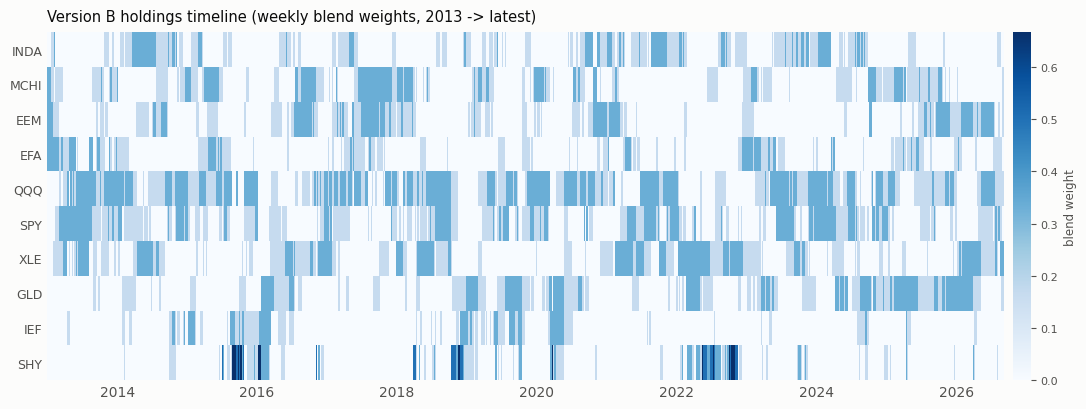

In [5]:
# Holdings timeline — which sleeve held when (blend weight, weekly)
w = res["weights"][UNIVERSE_B]
fig, ax = plt.subplots(figsize=(11, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(len(w.index) + 1)
mesh = ax.pcolormesh(w.index.append(w.index[-1:] + pd.Timedelta(weeks=1)),
                     np.arange(len(UNIVERSE_B) + 1), w.T.values,
                     cmap="Blues", vmin=0, vmax=2.0 / 3, shading="flat")
ax.set_yticks(np.arange(len(UNIVERSE_B)) + 0.5)
ax.set_yticklabels(UNIVERSE_B, fontsize=9, color="#0b0b0b")
ax.tick_params(colors="#52514e", length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(mesh, ax=ax, fraction=0.03, pad=0.01)
cb.set_label("blend weight", color="#52514e", fontsize=8.5)
cb.ax.tick_params(colors="#52514e", labelsize=8)
cb.outline.set_visible(False)
ax.set_title("Version B holdings timeline (weekly blend weights, 2013 -> latest)",
             color="#0b0b0b", fontsize=10.5, loc="left", pad=8)
plt.tight_layout()
plt.savefig("results/version_b_holdings_timeline.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

In [6]:
for num in ["TL_real", "USD"]:
    piv = res["regimes"][res["regimes"]["numeraire"] == num].pivot(
        index="regime", columns="strategy", values="ann_return")
    print("=== regimes, %s annualized return (%%) ===" % num)
    print((piv * 100).round(1).to_string())
    print()

=== regimes, TL_real annualized return (%) ===
strategy                  B2_SHY  B3_GLD   B5_EW  VB_net10
regime                                                    
2013-2017 pre-crisis      7.6000  1.2000 13.9000   14.2000
2018 crisis              19.3000 13.0000  6.3000   10.7000
2019-2020 COVID           8.2000 26.7000 22.0000   13.8000
2021-2023H1 infl. surge  10.8000 11.7000 14.9000   17.9000
2023H2-present orthodox -10.3000 10.1000 -1.8000   -2.3000

=== regimes, USD annualized return (%) ===
strategy                 B2_SHY  B3_GLD   B5_EW  VB_net10
regime                                                   
2013-2017 pre-crisis     0.4000 -5.6000  6.3000    6.6000
2018 crisis              1.2000 -4.1000 -9.8000   -6.1000
2019-2020 COVID          3.2000 20.8000 16.3000    8.4000
2021-2023H1 infl. surge -1.4000 -0.6000  2.3000    5.0000
2023H2-present orthodox  4.2000 31.4000 16.0000   18.9000



## Results & Interpretation

**Phase 1 complete (2026-08-22).** Version B — the fully implementable USD portfolio — backtested 2013-01-01 -> latest, tri-numeraire, gross/net10/net25.

**1. The headline real-TL result is honest and sobering: after costs, Version B ~ ties naive equal weight.**
Real TL: VB net10 11.1%/yr (3.9x, Sharpe 0.55) vs B5 EW 11.2%/yr (3.9x, Sharpe 0.57); real max-DD also
~equal (-36% both). Same story in USD on this window (Sharpe 0.72 vs 0.70). The momentum machinery's
USD-era edge was concentrated pre-2013 (secondary window 2008->: VB 0.70 vs EW 0.57, DD -18.6% vs -34.4%).
On the Turkish window, what active selection buys is *shape*, not headline growth: USD max-DD -18.6% vs
-24.3% EW, and +10.7%/yr real in the 2018 crisis vs +6.3% EW.

**2. Every diversified USD strategy crushed "just hold dollars" — until 2023.** B2 (SHY) made only 1.8x real
over the window vs VB's 3.9x — holding dollars halved the achievable real outcome. But the regime table's
last row is the essay's pivot: 2023H2 -> present, B2 = **-10.3%/yr real** (orthodox high rates -> TL real
appreciation), VB -2.3%/yr, only gold positive (+10.1%). **No USD-only allocation solves the post-2023
regime.** That is precisely the slot TL deposits (B1) occupy — the strongest possible setup for the A-B gap.

**3. Costs are existential at retail levels.** net25 falls to 8.1%/yr real (Sharpe 0.40) — *below* naive EW.
At 25 bps the entire active edge is gone; at 10 bps it breaks even with EW. Turnover 0.34/wk one-way
(~1.8%/yr at 10 bps, ~4.4%/yr at 25 bps). For the platform argument: weekly-rebalanced allocation for
Turkish retail is only viable with institutional-grade execution costs.

**4. Mechanics.** Avg 4.2 sleeves held; hatch (SHY) active 12.1% of weeks at avg weight 0.32 — dark SHY
bands in the holdings timeline mark the risk-off episodes (2015-16, 2018, 2022). The EM concentration gate genuinely binds: an ungated top-3 would hold MCHI and INDA together in 7.6% (10w) / 9.8% (25w) of weeks, clustered in 2014, 2017 and 2020 (diagnostic cell above).

**Caveats:** TL-real uses the PROVISIONAL IMF CPI (via DBnomics), truncating 2025-07; swap to TUIK/EVDS in
Phase 2 restores the tail — the missing 13 months are the heart of the orthodox regime, so the 2023H2 row
will sharpen. B1/B4/B6 benchmarks and the A-B gap are Phase 2. B5 EW is costless here; EW's own ~0.1%/yr
cost drag would not change any conclusion.

**Outputs written to `results/`:** stats CSVs (3 numeraires), regime CSV, weekly weights CSV (audit),
equity-curve and holdings-timeline PNGs.